This notebook has been created by

s204248, Freja Tusindfryd Dollas & s204229, Søren Stange

# Comparative Social Structures in Fictional Universes: Harry Potter and the Lord of the Rings

This is an explainer notebook made to show all of the programming which is the basis of the final project titled *Comparative Social Structures in Fictional Universes: A Network and Text Analysis of the Wizarding World of Harry Potter and the Lord of the Rings*.

### Introduction to the Notebook
This notebook has the following sections: 

*Utility functions*: 
Functions used when crawling and downloading data

*Download data*: 
We crawl through the two fandom.com wiki-sites corresponding to **Harry Potter** (https://harrypotter.fandom.com/wiki/Harry_Potter) and **Lord of the Rings** (https://lotr.fandom.com/wiki/Main_Page). 

We crawl through each category found on the pages https://harrypotter.fandom.com/wiki/Harry_Potter/Category:Individuals and https://lotr.fandom.com/wiki/Main_Page/Category:Characters and extract all wiki pages found on these sites. These sites are then pruned taking only the ones containing infoboxes which relate to characters of the two universes. 

Two networks can then be created, one for the Harry Potter universe and one for the Lord of the Rings universe. Here the nodes of each network is the pages of characters and links between nodes are the hyperlinks in the wiki-pages content. We prune the network by removing all nodes which either don't link to any other or are not linked to by other pages. We then perform a final pruning by only selecting the largest weakly connected component for each network.

From all of the characters pages we extract info from the infoboxes and store these as node attributes along side the total number of words on each page. The attributes from the infoboxes we save are Blood-status (Pure-blood, half-blood, muggle) and House (Gryffindor, Slytherin, Ravenclaw, Hufflepuff) for Harry Potter and Culture and species for Lord of the Rings.

*Create embedding*:
We use the implementation of the algorithm struc2vec from https://github.com/sebkaz/struc2vec/tree/master to create a vector representation of each node regarding their structural identity. This embedding will then be used in this notebook to determine role similarity between characters in the two character universes.

*Preliminary code*:
Usefull functions for this notebook regarding cowloading data and packages

#### Structure of the notebook
The rest of the notebook is structured as follows:
1) Network characterizations
2) Role similarity, data-mining, struc2vec
3) Sentiment analysis of the two universes

#### Utility functions

In [ ]:
import networkx as nx
import re, pickle, urllib.request, time, json, requests

#Define helper functions
def extract_infobox(content):
    # Step 1: find the starting point of the infobox
    start_match = re.search(r"\{\{[^{}]{0,50}?[Ii]nfobox", content, flags=re.IGNORECASE)
    if not start_match:
        return None

    start_index = start_match.start()

    # Step 2: walk forward and find the matching braces
    brace_count = 0
    i = start_index
    while i < len(content):
        if content[i:i+2] == "{{":
            brace_count += 1
            i += 2
            continue
        elif content[i:i+2] == "}}":
            brace_count -= 1
            i += 2
            if brace_count == 0:
                return content[start_index:i]  # extract full infobox
            continue
        else:
            i += 1

    return None  # fallback if somehow unbalanced

def extract_field(text, field):
    lines = text.splitlines()
    capture = False
    genre_lines = []
    for line in lines:
        if not capture:
            if re.match(rf'\|\s*{field}\s*=', line, flags=re.I):
                line = re.sub(rf'\|\s*{field}\s*=\s*', '', line, flags=re.I)
                genre_lines.append(line)
                capture = True
        else:
            if re.match(r'\|\s*\w+\s*=', line):
                break
            genre_lines.append(line)
    return '\n'.join(genre_lines).strip()

def extract_name(text):
    pattern = r"\[\[(.*?)\]\]"
    matches = re.findall(pattern, text)
    return matches

def extract_origin(text, field):
    return extract_name(extract_field(extract_infobox(text), field))

# Declare helper functions
def clean_links(links, node):
    arr = []
    for l in links:
        match = re.search(r'|', l)
        if match:
            splits = l.split(r'|')
            if splits[0].replace(' ', '_') == node: #Remove self-loops
                continue
            else:
                arr.append(splits[0].replace(' ', '_'))
        else:
            if l.replace(' ', '_') == node:
                continue
            else:
                arr.append(l.replace(' ', '_'))
    return arr

def analyze_node(data_point, field_origin, field_species):
    Node = data_point['page_name']
    text = data_point['content']
    words = len(text.split())
    try:
        origin = extract_origin(text, field_origin)
    except:
        origin = None

    try:
        species = extract_origin(text, field_species)
    except:
        species = None
    links_to = re.findall(r'\[\[([^\]]+)\]\]', text)
    links_to = clean_links(links_to, Node)
    return Node, links_to, words, origin, species

def create_network(data, field_origin, field_species, use_only_largest_component = False):
    for entry in data:
        entry['page_name'] = entry['page_name'].replace(' ','_')
    G = nx.DiGraph()
    non_links = []
    Nodes = list(set([data_point['page_name'] for data_point in data]))
    for data_point in data:
        Node, links_to, words, origin, species = analyze_node(data_point, field_origin, field_species)
        G.add_node(Node, words=words, origin = origin, species = species)
        for links_to_node in links_to:
            if links_to_node in Nodes:
                G.add_edge(Node, links_to_node)
            else:
                non_links.append(links_to_node)

    G = G.subgraph([node for node, deg in G.degree() if deg > 0])
    if use_only_largest_component:
        # Extract the largest component
        components = nx.weakly_connected_components(G)
        largest = max(components, key=len)
        G = G.subgraph(largest).copy()
    
    return G

def load_network(name = None):
    if name in ['HP', 'hp', 'Harry Potter']:
        with open("data/Harry_Potter_Wiki_pages.pkl", "rb") as f:   # 'rb' = read binary
            data = pickle.load(f)

        corrected_list = []
        for x in data:
            if 'Individual infobox' in x['content']:
                corrected_list.append(x)

        G = create_network(corrected_list, field_origin = 'house', field_species = 'blood', use_only_largest_component=True)
        nodes_w_in = [node for node, deg in G.in_degree() if deg > 0]
        nodes_w_out = [node for node, deg in G.out_degree() if deg > 0]

        nodes = list(set(nodes_w_in).intersection( set(nodes_w_out)))
        return G.subgraph(nodes).copy()
    
    elif name in ['LOTR', 'lotr', 'Lord of the Rings']:
        with open("data/Lord_of_the_rings_Wiki_pages.pkl", "rb") as f:   # 'rb' = read binary
            data = pickle.load(f)

        corrected_list = []
        for x in data:
            if 'Infobox Person' in x['content']:
                corrected_list.append(x)


        G = create_network(corrected_list, field_origin = 'culture', field_species = 'race', use_only_largest_component=True)

        nodes_w_in = [node for node, deg in G.in_degree() if deg > 0]
        nodes_w_out = [node for node, deg in G.out_degree() if deg > 0]

        nodes = list(set(nodes_w_in).intersection( set(nodes_w_out)))
        return G.subgraph(nodes).copy()
    
    else:
        HP = load_network('HP')
        LOTR = load_network('LOTR')
        return nx.union(HP, LOTR)
    

def load_LabTM():
    #download LabTM list for sentiment analysis

    # Direct URL to the raw LabMT file
    url = "https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0026752.s001&type=supplementary"

    # Download the file
    r = requests.get(url)
    r.raise_for_status()  # check if download worked
    text = r.text

    # Split into lines
    lines = text.splitlines()

    # Skip any lines before the header 
    header_index = 0
    for i, line in enumerate(lines):
        if line.startswith("word"):
            header_index = i
            break

    # Parse the header line
    columns = lines[header_index].split('\t')

    # Parse the remaining lines into a list of dictionaries
    data = []
    for line in lines[header_index+1:]:
        values = line.split('\t')
        if len(values) == len(columns):
            data.append(dict(zip(columns, values)))

    #  mapping word to happiness_average
    word_scores = {row['word']: float(row['happiness_average']) for row in data}
    return word_scores


#### Download data 
**This is used to download all of the character pages from the fandom.wiki pages of Lord of the Rings and Harry Potter**

In [ ]:
#Import all relevant libraries
import networkx as nx
import re, pickle, urllib.request, time, json

In [ ]:
#Define helper functions for data download
def download_pages(url, page_names, batch_size=25):
    api_url = f'https://{url}/api.php'
    results = []
    batches = range(0, len(page_names), batch_size)
    N = len(batches)
    print(f'Total number of batches: {N}. Total number of pages: {len(page_names)}')
    failed_batches = []

    for i in batches:
        batch = page_names[i:i+batch_size]
        clean_batch = [t for t in batch if t and not any(c in t for c in '\n\r{}')]
        if not clean_batch:
            continue

        data = {
            'action': 'query',
            'prop': 'revisions',
            'rvprop': 'content',
            'titles': '|'.join(clean_batch),
            'format': 'json'
        }

        encoded = urllib.parse.urlencode(data).encode('utf-8')
        request = urllib.request.Request(api_url, data=encoded)
        request.add_header('User-Agent', 'YourAppName/1.0 (s204229@student.dtu.dk)')

        try:
            with urllib.request.urlopen(request) as response:
                wikidata = json.loads(response.read())
                for key, page in wikidata['query']['pages'].items():
                    revisions = page.get('revisions', [{}])
                    content = revisions[0].get('*', '') if revisions else ''
                    results.append({
                        'page_name': page.get('title', ''),
                        'content': content
                    })
        except urllib.error.HTTPError as e:
            print(f"HTTP Error {e.code} on batch {i//batch_size + 1} / {N}: {e.reason}")
            failed_batches += batch
        time.sleep(1)
    return results, failed_batches

def get_all_characters(url, root_category):
    downloaded_categories = [root_category]
    response = get_category_members(url, root_category)
    characters, categories = extract_characters_and_categories(response, downloaded_categories)

    while categories:
        current = categories.pop(0)
        downloaded_categories.append(current)
        print(f"{len(categories)} remaining. Fetching: {current}")
        response = get_category_members(url, current)
        char, cat = extract_characters_and_categories(response, downloaded_categories)
        characters = list(set(characters + char))
        categories = list(set(categories + cat) )
        time.sleep(1)

    return sorted(set(characters))

def get_category_members(url, page_name):
    base_url = f'https://{url}/api.php?'
    query = (
        f"{base_url}"
        f"action=query&list=categorymembers&cmtitle={urllib.parse.quote(page_name)}"
        f"&cmlimit=max&format=json"
    )
    request = urllib.request.Request(query)
    request.add_header('User-Agent', 'YourAppName/1.0 (s204229@student.dtu.dk)')
    with urllib.request.urlopen(request) as response:
        wikidata = json.loads(response.read())
        return [member['title'] for member in wikidata['query']['categorymembers']]
    
def extract_characters_and_categories(response, downloaded_categories):
    # Words that indicate non-character categories
    '''blacklist = ['places', 'creatures', 'locations', 'objects', 'languages',
                 'rivers', 'mountains', 'events', 'battles', 'wars', 'books',
                 'families', 'songs', 'terms', 'legends', 'real-world', 'media', 
                 'non-canonical', 'images', 'ranks', 'titles']'''
    
    characters = []
    categories = []

    for title in response:
        if title.startswith('Category:'):
            # Normalize for comparison
            lower = title.lower()
            '''if any(bad in lower for bad in blacklist):
                continue  # skip non-character categories'''
            if title not in downloaded_categories:
                categories.append(title)
        else:
            # Keep only likely character pages (heuristic: no colon, not "Category:", not image)
            if ':' not in title and not title.lower().startswith('list of'):
                characters.append(title)
    return list(set(characters)), list(set(categories))

def download(url, start_page, output_name):
    page_names  = get_all_characters(url, start_page)
    pages, failed_batches = download_pages(url, page_names)
    print(len(failed_batches))
    while failed_batches:
        print(f'{len(failed_batches)} pages failed, and are being downloaded now')
        pages_b, failed_batches = download_pages(url, failed_batches)
        pages += pages_b
    with open(output_name, "wb") as f:   # 'wb' = write binary
        pickle.dump(pages, f)

In [ ]:
url         = 'harrypotter.fandom.com'
category    = 'Category:Individuals'
download(url, category, 'data/Harry_Potter_Wiki_pages.pkl')

In [ ]:
url         = 'lotr.fandom.com'
category    = 'Category:Characters'
download(url, category, 'data/Lord_of_the_rings_Wiki_pages.pkl')


#### Create embedding
**This uses the implementation of *struc2vec* from https://github.com/sebkaz/struc2vec/tree/master**

In [ ]:
#!pip install fastdtw futures gensim numpy scipy six smart-open

In [ ]:
import pickle, os, glob
import networkx as nx
from util import *

In [ ]:
def delete_pkl_files(folder_path = 'struc2vec-master\\pickles'):
    """
    Deletes all .pkl files in the given folder.

    Parameters:
        folder_path (str): Path to the folder where .pkl files should be removed.
    """
    pattern = os.path.join(folder_path, "*.pickle")
    for file_path in glob.glob(pattern):
        try:
            os.remove(file_path)
            print(f"Deleted: {file_path}")
        except Exception as e:
            print(f"Error deleting {file_path}: {e}")

In [ ]:
G = load_network()
mapping             = {old_label: i + 1 for i, old_label in enumerate(G.nodes())}
reversed_mapping    = {i + 1: old_label for i, old_label in enumerate(G.nodes())}
G                   = nx.relabel_nodes(G, mapping)
with open("data/mapping.pkl", "wb") as f:
    pickle.dump(mapping, f)
with open("data/reversed_mapping.pkl", "wb") as f:
    pickle.dump(reversed_mapping, f)

nx.write_edgelist(G, 'struc2vec-master\\graph\\graph.edgelist', data=False)

In [ ]:
delete_pkl_files()

In [ ]:
!python struc2vec-master/src/main.py --input struc2vec-master/graph/graph.edgelist --output data/embedding.emb --num-walks 50 --walk-length 100 --window-size 16 --dimensions 128 --iter 50 --directed --OPT1 True --OPT2 True --OPT3 True

#### Prelimary code

In [ ]:
# Import all relevant libraries and modules
import pickle, requests, math, powerlaw
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from gensim.models import KeyedVectors
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter

from util import *

In [ ]:
# Load the data and networks
G       = load_network()
HP      = load_network('HP')
LOTR    = load_network('LOTR')

with open("data/Harry_Potter_Wiki_pages.pkl", "rb") as f: 
    HP_data = pickle.load(f)
with open("data/Lord_of_the_rings_Wiki_pages.pkl", "rb") as f:   
    LOTR_data = pickle.load(f)

combined_data = {}
for page in HP_data:
    combined_data[page['page_name'].replace(' ', '_')] = page['content']
for page in LOTR_data:
    combined_data[page['page_name'].replace(' ', '_')] = page['content']
    
with open("data/mapping.pkl", "rb") as f:
    mapping = pickle.load(f)
with open("data/reversed_mapping.pkl", "rb") as f:
    reversed_mapping = pickle.load(f)

emb = KeyedVectors.load_word2vec_format(f"data/embedding.emb", binary=False)
word_scores = load_LabTM()  #download LabTM list for sentiment analysis

### 1) Network characterizations

In [28]:
#Helper functions
def plot_centrality_distributions(G, network_name="Network"):
    measures = {
        "Degree": nx.degree_centrality(G),
        "Betweenness": nx.betweenness_centrality(G),
        "Eigenvector": nx.eigenvector_centrality(G, max_iter=1000)
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for i, (name, centrality) in enumerate(measures.items()):
        sorted_vals = sorted(centrality.values(), reverse=True)
        axes[i].plot(sorted_vals, marker='o')
        axes[i].set_title(f"{name} Centrality")
        axes[i].set_xlabel("Nodes (sorted)")
        axes[i].set_ylabel("Centrality value")
    
    fig.suptitle(f"Centrality Distributions - {network_name}", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
    
    #top nodes
    for name, centrality in measures.items():
        top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
        print(f"\nTop 10 nodes by {name} Centrality ({network_name}):")
        for node, value in top_nodes:
            print(f"{node}: {value:.4f}")

def compare_degree_distributions(G1, G2, norma, label1="Harry Potter", label2="LOTR", bins=30):
    plt.style.use("seaborn-v0_8-whitegrid")
    
    colors = {label1: "#b51512", label2: "#1670c4"}
    deg_types = ["in", "out", "total"]
    
    # Extract degree lists
    degs1 = {
        "in": [deg for _, deg in G1.in_degree() if deg>0],
        "out": [deg for _, deg in G1.out_degree() if deg>0],
        "total": [deg for _, deg in G1.degree() if deg>0]
    }
    degs2 = {
        "in": [deg for _, deg in G2.in_degree() if deg>0],
        "out": [deg for _, deg in G2.out_degree() if deg>0],
        "total": [deg for _, deg in G2.degree() if deg>0]
    }
    
    alphas1 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs1.items()}
    alphas2 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs2.items()}
    
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    
    for i, dtype in enumerate(deg_types):
        max_deg = max(max(degs1[dtype]), max(degs2[dtype]))
        bins_arr = np.linspace(0, max_deg, bins+1)
        
        # Plot histograms
        if norma: 
            axes[i].hist(degs1[dtype], bins=bins_arr, alpha=0.6, color=colors[label1], label=label1, density=True)
            axes[i].hist(degs2[dtype], bins=bins_arr, alpha=0.6, color=colors[label2], label=label2, density=True,
                        histtype='step', linewidth=2)
            
            axes[i].set_xlabel("Degree")
            axes[i].set_ylabel("Fraction of nodes")
            axes[i].set_title(f"{dtype.capitalize()}-degree distribution")
        else: 
            axes[i].hist(degs1[dtype], bins=bins_arr, alpha=0.6, color=colors[label1], label=label1 )
            axes[i].hist(degs2[dtype], bins=bins_arr, alpha=0.6, color=colors[label2], label=label2,
                        histtype='step', linewidth=2)
            
            axes[i].set_xlabel("Degree")
            axes[i].set_ylabel("Number of nodes")
            axes[i].set_title(f"{dtype.capitalize()}-degree distribution")
        # Only show legend on first subplot, lower-right corner
        if i == 0:
            axes[i].legend(loc='lower right')
        
        # Alpha text in top-right corner
        axes[i].text(0.95, 0.95, f"{label1} α={alphas1[dtype]:.2f}\n{label2} α={alphas2[dtype]:.2f}", 
                     transform=axes[i].transAxes, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    fig.suptitle("Degree Distributions Comparison", fontsize=16, weight='bold')
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# --- Helper function: Freeman centralization ---
def freeman_centralization(centrality_dict):
    """Compute Freeman centralization for any centrality dict (values normalized 0-1)."""
    n = len(centrality_dict)
    max_c = max(centrality_dict.values())
    return sum(max_c - c for c in centrality_dict.values()) / (n - 1)

# --- Helper function: Gini coefficient ---
def gini(array):
    """Compute Gini coefficient of a numpy array"""
    array = np.array(array)
    if np.all(array == 0):
        return 0.0
    array = np.sort(array)
    n = array.shape[0]
    cumvals = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

def global_reaching_centrality(DG):
    """
    Directed Global Reaching Centrality (GRC).
    GRC = (1/(N-1)) * sum(max_reach - reach_i),
    where reach_i is fraction of nodes reachable from i (excluding i)
    following the definition of Coscia.
    """
    N = DG.number_of_nodes()
    if N <= 1:
        return 0.0
    # Precompute reach sizes
    reach_fracs = []
    nodes = list(DG.nodes())
    for u in nodes:
        # number of reachable nodes from u via directed paths (exclude u)
        reachable = nx.descendants(DG, u)  # uses directed reachability
        reach_fracs.append(len(reachable) / (N - 1))
    max_reach = max(reach_fracs) if reach_fracs else 0.0
    grc = sum(max_reach - r for r in reach_fracs) / (N - 1)
    return grc

# --- Analysis function ---
def analyze_network(G, name="Network"):
    n_nodes = len(G.nodes)
    n_edges = len(G.edges)
    avg_degree = sum(dict(G.degree()).values()) / n_nodes
    avg_clustering = nx.average_clustering(G)
    
    # Centrality metrics
    deg_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G, normalized=True)
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    
    # Freeman centralization
    deg_centralization = freeman_centralization(deg_cent)
    bet_centralization = freeman_centralization(bet_cent)
    eig_centralization = freeman_centralization(eig_cent)
    
    # Gini coefficients (hierarchy measure)
    gini_degree = gini(list(dict(G.degree()).values()))
    gini_bet = gini(list(bet_cent.values()))
    gini_eig = gini(list(eig_cent.values()))
    
     # Global Reaching Centrality
    grc = global_reaching_centrality(G)

    
    # Summary dictionary
    summary = {
        "Nodes": n_nodes,
        "Edges": n_edges,
        "Avg Degree": avg_degree,
        "Avg Clustering": avg_clustering,
        "Degree Centralization": deg_centralization,
        "Betweenness Centralization": bet_centralization,
        "Eigenvector Centralization": eig_centralization,
        "Gini Degree": gini_degree,
        "Gini Betweenness": gini_bet, 
        "Gini Eigenvector": gini_eig,
        "Global reaching centrality": grc
    }
    
    return summary, deg_cent, bet_cent, eig_cent

#### Distributions: centrality and degree

We struggled a bit with how to best visualize the degree distribution as the size of the two networks are very different. We normalized the number of nodes and tried to plot the cdf. 



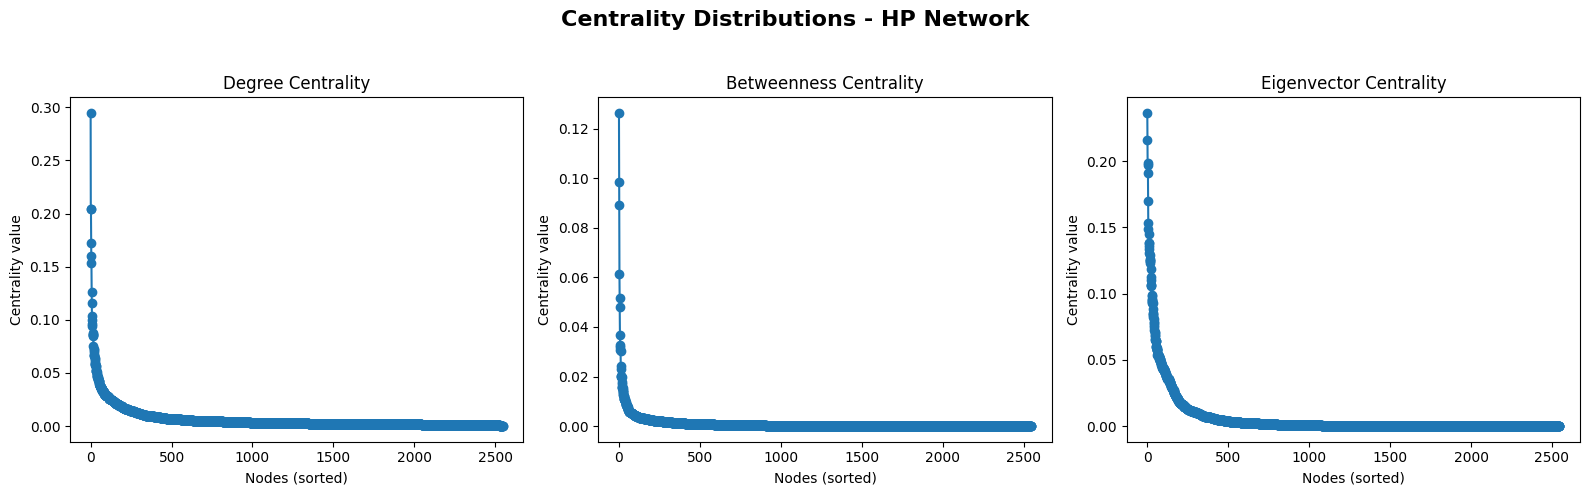


Top 10 nodes by Degree Centrality (HP Network):
Harry_Potter: 0.2946
Tom_Riddle: 0.2046
Albus_Dumbledore: 0.2038
Jacob's_sibling: 0.1724
Ronald_Weasley: 0.1599
Hermione_Granger: 0.1532
Minerva_McGonagall: 0.1261
Severus_Snape: 0.1159
Rubeus_Hagrid: 0.1033
Sirius_Black: 0.0994

Top 10 nodes by Betweenness Centrality (HP Network):
Harry_Potter: 0.1263
Albus_Dumbledore: 0.0984
Jacob's_sibling: 0.0891
Minerva_McGonagall: 0.0614
Tom_Riddle: 0.0517
Unidentified_19th-century_Hogwarts_student: 0.0480
Tiburon_Merriweather's_great-grandchild: 0.0366
Hermione_Granger: 0.0328
Phineas_Nigellus_Black: 0.0319
Ronald_Weasley: 0.0307

Top 10 nodes by Eigenvector Centrality (HP Network):
Harry_Potter: 0.2364
Tom_Riddle: 0.2162
Albus_Dumbledore: 0.1989
Ronald_Weasley: 0.1971
Hermione_Granger: 0.1912
Severus_Snape: 0.1700
Draco_Malfoy: 0.1532
Sirius_Black: 0.1488
Ginevra_Weasley: 0.1453
Neville_Longbottom: 0.1383


In [8]:

plot_centrality_distributions(HP, network_name="HP Network")

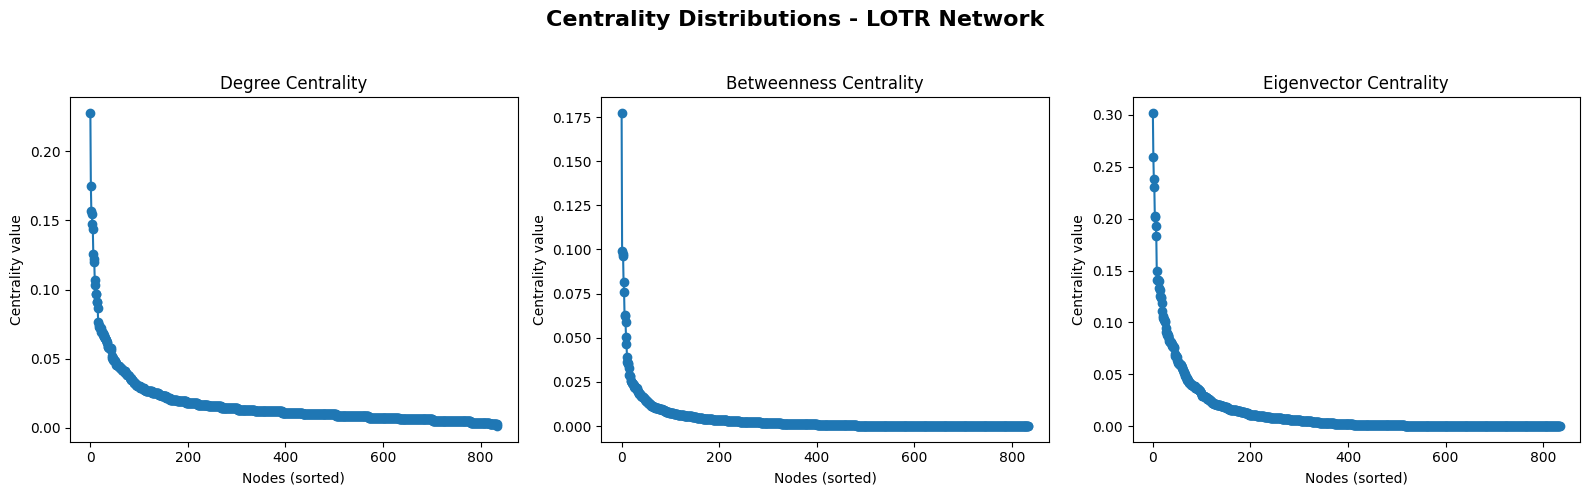


Top 10 nodes by Degree Centrality (LOTR Network):
Sauron: 0.2278
Gandalf: 0.1751
Frodo_Baggins: 0.1571
Bilbo_Baggins: 0.1547
Aragorn_II: 0.1475
Morgoth: 0.1439
Elrond: 0.1259
Saruman: 0.1223
Galadriel: 0.1199
Samwise_Gamgee: 0.1067

Top 10 nodes by Betweenness Centrality (LOTR Network):
Sauron: 0.1773
Aragorn_II: 0.0993
Frodo_Baggins: 0.0973
Bilbo_Baggins: 0.0965
Gandalf: 0.0815
Morgoth: 0.0761
Galadriel: 0.0628
Saruman: 0.0623
Samwise_Gamgee: 0.0590
Elrond: 0.0506

Top 10 nodes by Eigenvector Centrality (LOTR Network):
Sauron: 0.3019
Gandalf: 0.2593
Aragorn_II: 0.2378
Elrond: 0.2301
Frodo_Baggins: 0.2025
Galadriel: 0.2018
Saruman: 0.1928
Bilbo_Baggins: 0.1835
Legolas: 0.1494
Peregrin_Took: 0.1408


In [9]:
plot_centrality_distributions(LOTR, network_name="LOTR Network")

We look at the top 6 nodes by centrality measures in the HP and LOTR networks. For the Harry Potter network we find that the centrality measures of interactions are dominated by a small group of characters, namely Harry Potter, Tom Riddle (Voldemort) Albus Dumbledore, Hermione Granger and Ronald Weasley. From the betweeness centrality it is clear that they act as connectors between otherwise unrelated characters and from the eigenvector centrality we see that they are connected to other influential nodes. This indicates that the mentioned characters are the core of the structure, where about the interactions and narrative are centralized. However, we see the characters "Unidentified 19th-century Hogwarts student" and "Jacob's sibling" which in spite of their names have surpringsinly long entries and therefore are highly linked. This pattern is the same for the Lord of the Rings network. Here we see that characters such as Sauron, Gandalf, Frodo Baggins and Aragorn II  are central in all centrality measures.

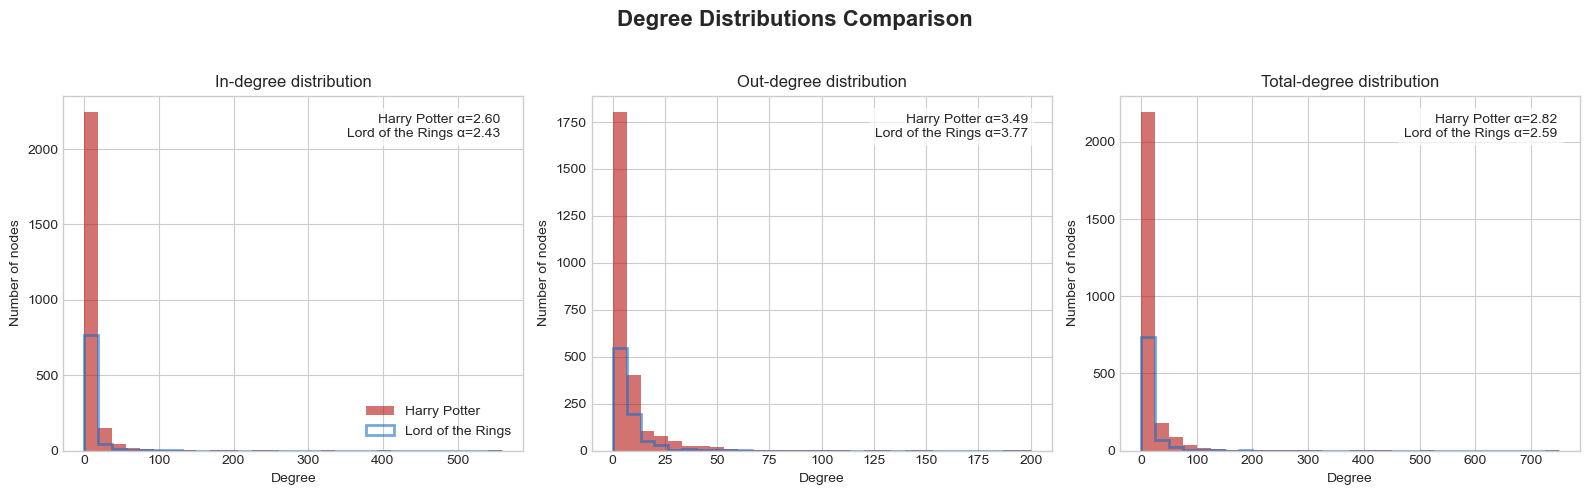

In [32]:
compare_degree_distributions(HP, LOTR, norma = False, label1="Harry Potter", label2="Lord of the Rings")

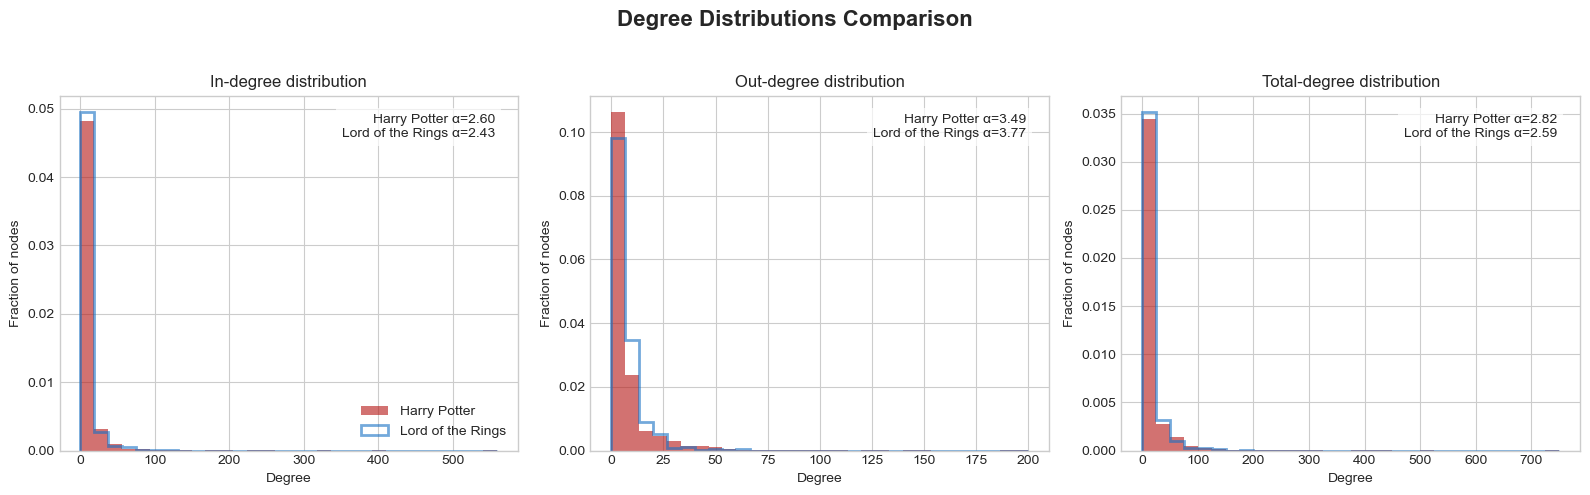

In [33]:
compare_degree_distributions(HP, LOTR, norma = True,label1="Harry Potter", label2="Lord of the Rings")

Degree distribution of in-, out and total degree of the HP and LOTR network. For the Harry Potter network with $\alpha=2.60$ for in-degree it is clear that most nodes have a low degree, for most below 40, while a few have more than 500. For the out-degree with $\alpha=3.49$ we see the same pattern, where most nodes have low degree (less than 20), with a few reaching up to 200. This is also reflected in the total degree distribution with $\alpha=2.82$, showing that the majority of nodes have relatively few connections, while a small number of nodes are highly connected. For the LOTR network with $\alpha=2.43$ it is clear that most nodes have a low in-degree, for most below 50, while a few has up to 160. For the out-degree with $\alpha=3.77$ we see  most nodes have low degree (less than 40), with a few reaching 70. This is very much the same values for total degree distribution with $\alpha=2.59$.

In [11]:
def compare_degree_distributions2(G1, G2, label1="Harry Potter", label2="LOTR", bins=30):
    plt.style.use("seaborn-v0_8-whitegrid")
    
    colors = {label1: "#b51512", label2: "#1670c4"}
    deg_types = ["in", "out", "total"]
    
    # Extract degree lists
    degs1 = {
        "in": [deg for _, deg in G1.in_degree() if deg>0],
        "out": [deg for _, deg in G1.out_degree() if deg>0],
        "total": [deg for _, deg in G1.degree() if deg>0]
    }
    degs2 = {
        "in": [deg for _, deg in G2.in_degree() if deg>0],
        "out": [deg for _, deg in G2.out_degree() if deg>0],
        "total": [deg for _, deg in G2.degree() if deg>0]
    }
    
    alphas1 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs1.items()}
    alphas2 = {k: powerlaw.Fit(v, verbose=False).alpha for k,v in degs2.items()}
    
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    
    def plot_cdf(ax, data, color, label):
        """Plot an empirical CDF."""
        sorted_data = np.sort(data)
        yvals = np.arange(1, len(sorted_data)+1) / len(sorted_data)
        ax.step(sorted_data, yvals, where='post', color=color, linewidth=2, label=label)
    
    for i, dtype in enumerate(deg_types):
        ax = axes[i]

        # Plot CDFs instead of histograms
        plot_cdf(ax, degs1[dtype], colors[label1], label1)
        plot_cdf(ax, degs2[dtype], colors[label2], label2)

        ax.set_xlabel("Degree")
        ax.set_ylabel("CDF")
        ax.set_title(f"{dtype.capitalize()}-degree distribution (CDF)")

        if i == 0:
            ax.legend(loc='lower right')

        ax.text(
            0.95, 0.05,
            f"{label1} α={alphas1[dtype]:.2f}\n{label2} α={alphas2[dtype]:.2f}",
            transform=ax.transAxes,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    fig.suptitle("Degree Distributions Comparison (CDF)", fontsize=16, weight='bold')
    fig.tight_layout(rect=[0,0,1,0.95])
    plt.show()


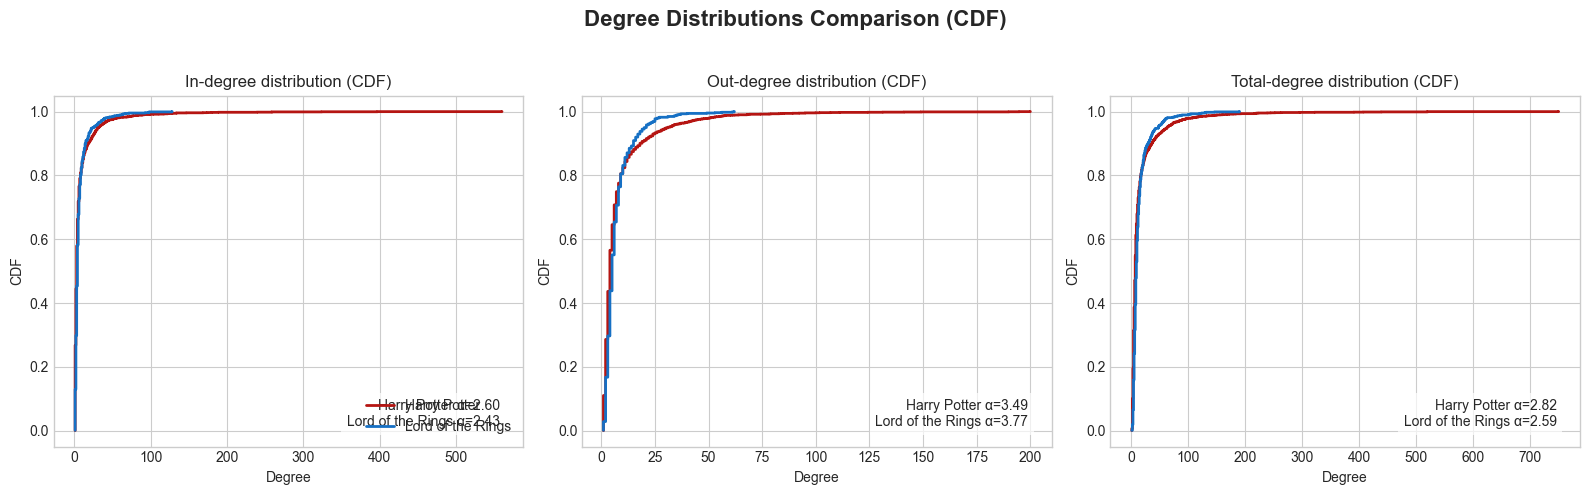

In [12]:
compare_degree_distributions2(HP, LOTR, label1="Harry Potter", label2="Lord of the Rings")

#### Network metrics; centralization (Freeman), Gini, GCR

In [13]:
# --- Run analysis for both networks ---
summary_HP, deg_HP, bet_HP, eig_HP = analyze_network(HP, "Harry Potter")
summary_LOTR, deg_LOTR, bet_LOTR, eig_LOTR = analyze_network(LOTR, "LOTR")

# --- Print summary table ---
import pandas as pd
df = pd.DataFrame([summary_HP, summary_LOTR], index=["Harry Potter", "LOTR"])
print(df[["Nodes","Edges","Avg Degree","Avg Clustering",
         "Degree Centralization","Betweenness Centralization",
         "Eigenvector Centralization","Gini Degree","Gini Betweenness", "Gini Eigenvector", "Global reaching centrality"]])

              Nodes  Edges  Avg Degree  Avg Clustering  Degree Centralization  \
Harry Potter   2547  20868   16.386337        0.486444               0.288257   
LOTR            835   5947   14.244311        0.419984               0.210991   

              Betweenness Centralization  Eigenvector Centralization  \
Harry Potter                    0.125438                    0.230671   
LOTR                            0.173573                    0.288667   

              Gini Degree  Gini Betweenness  Gini Eigenvector  \
Harry Potter     0.628573          0.875084          0.881098   
LOTR             0.475670          0.795368          0.805021   

              Global reaching centrality  
Harry Potter                    0.021691  
LOTR                            0.008195  


Comparison of network-level metrics between the Harry Potter and Lord of the Rings networks. We see that the Harry Potter network is slightly more centralized than the Lord of the Rings network in terms of degree (0.29 vs. 0.21). For betweenness centrality, we see that LOTR has a slightly higher Freeman centralization (0.17 vs. 0.13) as well as eigenvector centrality (0.29 vs 0.23). We obtain Gini for total degree of 0.63 for HP and 0.48 for LOTR, so the inequlity in respect to the total degree of nodes is rather high for HP network and slightly lower for LOTR. This means that a fewer number of nodes in the HP network receive more activity where the activity in LOTR is more equally distributed between nodes. We obtain Gini for betweeness of 0.88 for HP and 0.80 for LOTR which both are very high values, indicating that few nodes act as bridges between different parts of the network. However, the value of the HP network is most extreme. Lastly Gini for Eigenvector of 0.88 for Hp and 0.81 for LOTR shows that influence is more concentrated in the HP network, where a small group of characters are most central. LOTR network also has a very influential group, however it is broader than that of HP. %For the core-periphery fit we obtain values of 0.592 for the Harry Potter network and 0.410 for the LOTR network, and 
Lastly for the global reaching centrality we obtain values of 0.022 for Hp and 0.0082 for LOTR. 

#### PageRank

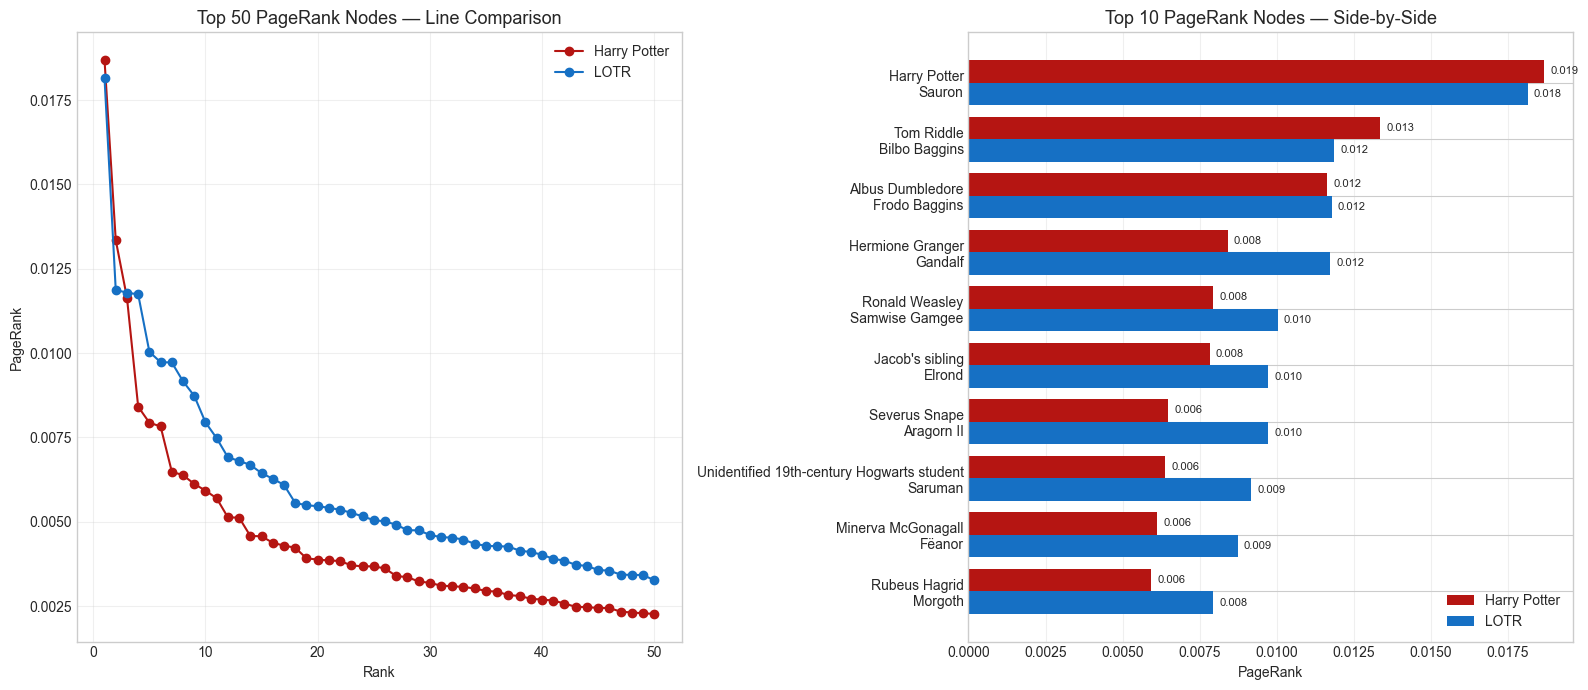

In [14]:
# Compute PageRank
pr_HP = nx.pagerank(HP)
pr_LOTR = nx.pagerank(LOTR)

# Extract scores
scores_HP = list(pr_HP.values())
scores_LOTR = list(pr_LOTR.values())

#helper
def clean_name(name):
    return name.replace("_", " ")

def get_top(pr, n):
    top = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:n]
    names = [clean_name(node) for node, _ in top]
    scores = [score for _, score in top]
    return names, scores


top_n_line = 50
top_n_bar = 10

# Line plot values
top_hp_line = sorted(pr_HP.items(), key=lambda x: x[1], reverse=True)[:top_n_line]
top_lotr_line = sorted(pr_LOTR.items(), key=lambda x: x[1], reverse=True)[:top_n_line]

hp_scores_line = [v for _, v in top_hp_line]
lotr_scores_line = [v for _, v in top_lotr_line]

# Bar plot values
names_hp_bar, scores_hp_bar = get_top(pr_HP, top_n_bar)
names_lotr_bar, scores_lotr_bar = get_top(pr_LOTR, top_n_bar)

# Reverse for horizontal bars
names_hp_bar = names_hp_bar[::-1]
scores_hp_bar = scores_hp_bar[::-1]
names_lotr_bar = names_lotr_bar[::-1]
scores_lotr_bar = scores_lotr_bar[::-1]

#figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

#Top 50 plot
ax1.plot(range(1, top_n_line + 1), hp_scores_line, marker='o',
         label="Harry Potter", color="#b51512")
ax1.plot(range(1, top_n_line + 1), lotr_scores_line, marker='o',
         label="LOTR", color="#1670c4")

ax1.set_title("Top 50 PageRank Nodes — Line Comparison", fontsize=13)
ax1.set_xlabel("Rank")
ax1.set_ylabel("PageRank")
ax1.legend()
ax1.grid(alpha=0.3)


#top 10 bar plot
ind = np.arange(top_n_bar)
width = 0.4

ax2.barh(ind + width/2, scores_hp_bar, height=width, label="Harry Potter", color="#b51512")
ax2.barh(ind - width/2, scores_lotr_bar, height=width, label="LOTR", color="#1670c4")

# Combined y-tick labels (HP over LOTR)
combined_labels = [f"{hp}\n{lotr}" for hp, lotr in zip(names_hp_bar, names_lotr_bar)]
ax2.set_yticks(ind)
ax2.set_yticklabels(combined_labels)

# Add values
for i in range(top_n_bar):
    ax2.text(scores_hp_bar[i] + 0.0002, ind[i] + width/2, f"{scores_hp_bar[i]:.3f}",
             va='center', fontsize=8)
    ax2.text(scores_lotr_bar[i] + 0.0002, ind[i] - width/2, f"{scores_lotr_bar[i]:.3f}",
             va='center', fontsize=8)

ax2.set_title("Top 10 PageRank Nodes — Side-by-Side", fontsize=13)
ax2.set_xlabel("PageRank")
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


PageRank comparison of top ranked nodes in the two networks. For both networks we see the top 20 PageRank nodes are significantly higher ranked than the rest of the nodes, while the PageRank for the rest of the nodes follow a more even tendency. Especially the top four PageRank nodes of the LOTR network are significantly higher ranked than the rest of the nodes with the first being significantly higher than the rest (that is Sauron). For the Harry Potter network we see that top five nodes are significantly higher ranked than the remainder nodes with the highest two nodes exhibiting a particularly wide spread (that is Harry Potter and Tom Riddle (Voldemort). We see that only the PageRank for the two highest nodes of HP network are higher ranked than those of the LOTR network. It makes sense that the general PageRank of nodes in LOTR network are higher, because there are much fewer nodes in this network.

#### Assortativity

In [15]:
#normalize species

import networkx as nx

# Define mapping
normalize_species = {
    'men': 'Men',
    'hobbit': 'Hobbits',
    'hobbits': 'Hobbits',
    'half-elf': 'Half-elves',
    'half-elves': 'Half-elves',
    'elves': 'Elves',
    'elf': 'Elves',
    'uruk-hai': 'Uruk-hai',
    'orc': 'Orcs',
    'orcs': 'Orcs',
    'dwarves': 'Dwarves',
    'dragon': 'Dragons',
    'dragons': 'Dragons',
    'ent': 'Ents',
    'ents': 'Ents',
    'valar': 'Valar',
    'cats': 'Cats',
}

species_attr = {}
for n, data in LOTR.nodes(data=True):
    species = data.get("species", [])
    if species is None:
        species_list = []
    elif isinstance(species, str):
        species_list = [species]
    else:
        species_list = species

    canonical = 'Other'
    for s in species_list:
        s_lower = s.lower().split('|')[0]  # handle "Men|mortal" -> "men"
        if s_lower in normalize_species:
            canonical = normalize_species[s_lower]
            break
    species_attr[n] = canonical

# Assign as node attribute
nx.set_node_attributes(LOTR, species_attr, name='species_canonical')




In [16]:
from collections import Counter

# The 4 Hogwarts houses
houses = ["gryffindor", "slytherin", "hufflepuff", "ravenclaw"]

house_counts = Counter()
other_origins = Counter()

for _, data in HP.nodes(data=True):
    origin = data.get("origin", None)

    if origin is None:
        origins = ["None"]
    elif isinstance(origin, str):
        origins = origin.split("|")
    else:
        origins = origin

    origins = [o.strip() for o in origins]

    matched = False
    for o in origins:
        o_low = o.lower()

        # Match Hogwarts houses
        for h in houses:
            if h == o_low:  # strict match
                house_counts[h.capitalize()] += 1
                matched = True
                break

    # If no house matched add origins to "Other"
    if not matched:
        for o in origins:
            other_origins[o] += 1



houses = ["gryffindor", "slytherin", "hufflepuff", "ravenclaw"]

for node, data in HP.nodes(data=True):
    origin = data.get("origin", None)

    if origin is None:
        origins = []
    elif isinstance(origin, str):
        origins = origin.split("|")
    else:
        origins = origin

    origins = [o.strip().lower() for o in origins]

    # Default
    assigned = "Other"

    for h in houses:
        if h in origins:
            assigned = h.capitalize()
            break

    HP.nodes[node]["house_label"] = assigned

house_to_int = {
    "Gryffindor": 0,
    "Slytherin": 1,
    "Hufflepuff": 2,
    "Ravenclaw": 3,
    "Other": 4
}

for n, data in HP.nodes(data=True):
    data["house_numeric"] = house_to_int[data["house_label"]]


In [17]:


degree_assortativity_LOTR = nx.degree_assortativity_coefficient(LOTR)
print("Degree assortativity LOTR:", degree_assortativity_LOTR)

words_assortativity_LOTR = nx.attribute_assortativity_coefficient(LOTR, "words")
print("Words (content length) assortativity LOTR:", words_assortativity_LOTR)

degree_assortativity_HP = nx.degree_assortativity_coefficient(HP)
print("Degree assortativity HP:", degree_assortativity_HP)

words_assortativity_HP = nx.attribute_assortativity_coefficient(HP, "words")
print("Words (content length) assortativity HP:", words_assortativity_HP)

species_assortativity_LOTR = nx.attribute_assortativity_coefficient(LOTR, 'species_canonical')
print("Species assortativity LOTR:", species_assortativity_LOTR)

house_assortativity_HP = nx.attribute_assortativity_coefficient(HP,"house_numeric")
print("Hogwarts house assortativity HP:", house_assortativity_HP)


Degree assortativity LOTR: 0.10131955451481382
Words (content length) assortativity LOTR: -0.0026055742583274647
Degree assortativity HP: -0.025107714571556073
Words (content length) assortativity HP: -0.0007988340508449617
Species assortativity LOTR: 0.5228553374365311
Hogwarts house assortativity HP: 0.17916444918249946


### 2) Role similarity, data-mining, struc2vec

In [ ]:
#Helper functions here
def create_X(emb = emb):
    word_vectors = []

    for key in emb.index_to_key:
        word_vectors.append((int(key), emb[key]))

    word_vectors = sorted(word_vectors, key = lambda x: x[0])

    X = np.array([snd for _, snd in word_vectors])
    return (X - np.mean(X, axis = 0)) / np.std(X, axis = 0)

def select_best_gmm_k(X, k_min=2, k_max=30):
    bic_scores = []
    gmms = []
    
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            random_state=42
        )
        gmm.fit(X)
        bic = gmm.bic(X)
        bic_scores.append(bic)
        gmms.append(gmm)

    best_idx = np.argmin(bic_scores)
    best_k = k_min + best_idx
    best_gmm = gmms[best_idx]
    
    print(f"Best number of clusters (BIC): {best_k}")
    return best_k, best_gmm, bic_scores


# Declare helper functions
def create_corpus(wikipedia_data, partition, filter_n = 5):
    corpus = {}
    if isinstance(partition, dict):
        for key, nodes in partition.items():
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data.get(node, "")

    elif isinstance(partition, list):
        for i, nodes in enumerate(partition):
            key = f'Community {i+1}'
            corpus[key] = ''
            for node in nodes:
                corpus[key] += wikipedia_data.get(node, "")

    lemmatizer = WordNetLemmatizer()
    for key, item in corpus.items():
        tokens = word_tokenize(item)
        tokens = [word for word in tokens if word.isalnum()]
        tokens = [word.lower() for word in tokens]
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        word_counts = Counter(tokens)
        tokens = [word for word in tokens if word_counts[word] >= filter_n]
        token_counts = {word: count for word, count in word_counts.items() if count >= filter_n}
        token_counts = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
        corpus[key] = token_counts
    return corpus

def TF_IDF(corpus):
    corpus = corpus.copy()
    total_number_of_documents = len(corpus)
    word_list = {}
    for key, document in corpus.items():
        for word, amount in document:
            if word not in word_list:
                word_list[word] = 1
            else:
                word_list[word] += 1
    
    for key, document in corpus.items():
        total_number_of_words = sum([amount for _, amount in document])
        new_document = []
        for word, amount in document:
            TF = amount / total_number_of_words
            IDF = np.log(total_number_of_documents / word_list[word])
            new_document.append((word, amount, TF, IDF, TF * IDF))
            
        corpus[key] = sorted(new_document, key = lambda x: x[4], reverse=True)
    
    return corpus

def create_wordclouds(corpus, width = 400, height = 300):

    def normalize(x, a, b):
            return (x-b)/(a-b) * 1000
    n = len(corpus)
    if n == 0:
        print("Corpus is empty.")
        return

    # --- Figure layout ---
    rows = 2  # number of columns in the grid
    cols = math.ceil(n / rows)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8))
    axes = axes.flatten() if n > 1 else [axes]

    # --- Create word clouds for each community ---
    for i, (key, token_counts) in enumerate(corpus.items()):
        # Convert list of tuples into a frequency dictionary
        TF_IDF_list = [TF_IDF for _,_,_,_,TF_IDF in token_counts]
        max_, min_ = max(TF_IDF_list), min(TF_IDF_list)
        
        freq_dict = []
        for word, _, _, _, TF_IDF in token_counts:
            freq_dict.append((word, normalize(TF_IDF, max_, min_)))
        freq_dict = dict(freq_dict)
        if not freq_dict:
            axes[i].set_visible(False)
            continue

        wc = WordCloud(
            width=width,
            height=height,
            background_color='white',
            colormap='viridis',
            random_state=42
        ).generate_from_frequencies(freq_dict)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(key, fontsize=16)
        axes[i].axis('off')

    # --- Hide any unused subplots ---
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def get_X_most_common_words(corpus, X = 10):
    for key, item in corpus.items():
        top_x = [word for word, _, _, _, _ in item[:X]]
        print(f'Group {key}: {top_x}')

def disparity_filter(G, alpha_threshold):
    # Create an empty graph of the same type
    backbone = G.__class__()
    backbone.add_nodes_from(G.nodes(data=True))

    # Compute normalized weights and significance for each node
    for i in G.nodes():
        k_i = len(G[i])
        if k_i <= 1:
            continue

        s_i = sum(G[i][j].get('viz_weight', 1.0) for j in G[i])
        for j in G[i]:
            w_ij = G[i][j].get('viz_weight', 1.0)
            p_ij = w_ij / s_i
            alpha_ij = 1 - (1 - p_ij) ** (k_i - 1)
            G[i][j]['alpha_' + str(i)] = alpha_ij

    # For undirected graphs, use the maximum significance (conservative choice)
    if not G.is_directed():
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            alpha_j = data.get('alpha_' + str(j), 1)
            alpha = min(alpha_i, alpha_j)
            if alpha < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha})
    else:
        for i, j, data in G.edges(data=True):
            alpha_i = data.get('alpha_' + str(i), 1)
            if alpha_i < alpha_threshold:
                backbone.add_edge(i, j, **{'viz_weight': data.get('viz_weight', 1.0), 'alpha': alpha_i})

    return backbone


def normalize(x, min_, max_):
    return (x - min_) / (max_ - min_) * 100


def calculate_sentiment(tokens, word_scores):
    valid_scores = [word_scores[w] for w in tokens if w in word_scores]
    if not valid_scores:
        return np.nan
    return np.mean(valid_scores)

def sentiment(G, data = combined_data, word_scores = word_scores):
    sentiments = {}
    for node in G.nodes():
        tokens = word_tokenize(data.get(node))
        tokens = [t.lower() for t in tokens if t.isalpha()]
        sentiments[node] = calculate_sentiment(tokens, word_scores)

    return sentiments


In [74]:
def plot_pca_first_two(Z, labels, highlight_dict=None):
    """
    Z: embedding matrix
    labels: list/array of labels for colors
    highlight_dict: dictionary {index: "name"} for highlighted nodes
    """
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z)

    labels = np.array(labels)
    unique_labels = np.unique(labels)

    plt.figure(figsize=(7, 7))

    # Plot groups
    for lab in unique_labels:
        idx = labels == lab
        plt.scatter(
            Z_pca[idx, 0],
            Z_pca[idx, 1],
            label=f'Group {lab}',
            alpha=0.7
        )

    # -----------------------------------------------------
    # STACKED LABEL PANEL (Right side, sorted by y-value)
    # -----------------------------------------------------
    if highlight_dict is not None and len(highlight_dict) > 0:

        # Sort highlight indices by DESCENDING y-coordinate
        sorted_items = sorted(
            highlight_dict.items(),
            key=lambda kv: Z_pca[kv[0], 1],   # sort by y-coordinate
            reverse=True                      # highest y first
        )

        x_coords = Z_pca[:, 0]
        panel_x = np.max(x_coords) + (np.max(x_coords) - np.min(x_coords)) * 0.10

        num_labels = len(sorted_items)

        panel_y_start = np.max(Z_pca[:, 1])
        spacing = (np.max(Z_pca[:, 1]) - np.min(Z_pca[:, 1])) / (num_labels + 1)

        # Draw sorted labels
        for i, (idx, name) in enumerate(sorted_items):
            px, py = Z_pca[idx]

            # Position for stacked label
            label_x = panel_x
            label_y = panel_y_start - (i + 1) * spacing

            # Connecting line
            plt.plot(
                [px, label_x],
                [py, label_y],
                linestyle="--",
                linewidth=0.8,
                color="black"
            )

            # Highlighted point marker
            plt.scatter(
                px, py,
                color="black",
                marker="*",
                s=180,
                edgecolor="white",
                linewidth=1.0,
                zorder=5
            )

            # Stacked text label
            plt.text(
                label_x,
                label_y,
                name.replace('_', ' '),
                fontsize=14,
                verticalalignment="center"
            )

    plt.xlabel("Principal Component 1", fontsize = 14)
    plt.ylabel("Principal Component 2", fontsize = 14)
    plt.title("PCA Plot of the struc2vec embedding", fontsize=20)
    plt.legend(fontsize = 14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return Z_pca


Best number of clusters (BIC): 7


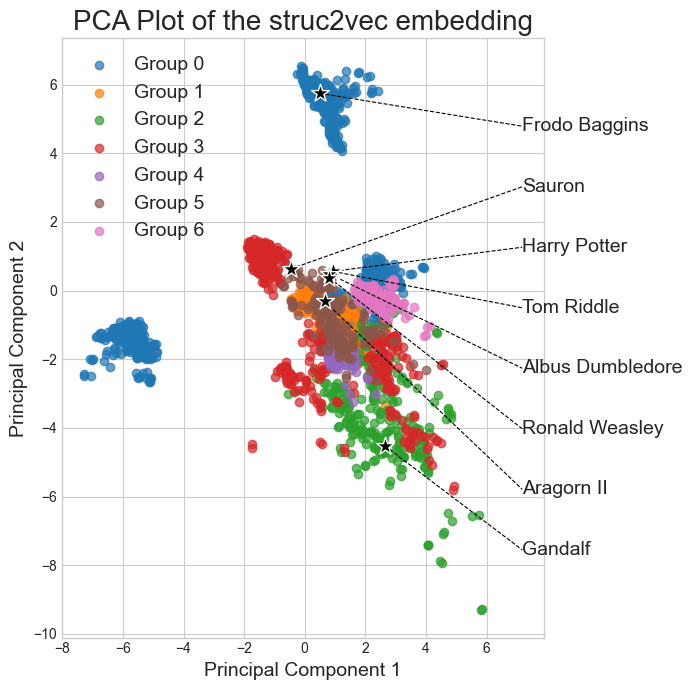

In [77]:
# Struc2vec kode her

# Train a gaussian mixture model to find clusters of similar nodes
X = create_X()
X = X.astype(np.float64)
best_k, best_gmm, bic_scores = select_best_gmm_k(X) # Find the best GMM with regard to the bayesian information criterion
result = best_gmm.predict(X)
groups = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    groups[x] = {'Names' : lst, 'index' : idx}

partition = {}
for x in set(result):
    idx = np.where(result == x)[0] + 1
    lst = [reversed_mapping[i] for i in idx]
    partition[x] = lst

P = {}
for n in G.nodes():
    for key, item in partition.items():
        if n in item:
            P[n] = key

names = ['Harry_Potter', 'Tom_Riddle', 'Albus_Dumbledore', 'Ronald_Weasley', 'Gandalf', 'Sauron', 'Frodo_Baggins', 'Aragorn_II']
names = {idx-1 : name for name, idx in mapping.items() if name in names}
Z_pca = plot_pca_first_two(X, result, names)


In [84]:
sent = sentiment(G)

metrics = {
    key: {'sentiment': [], 'length of content': [], 'degree': []}
    for key in partition.keys()
}

degrees = G.degree()

for node, sentiment_score in sent.items():
    for key, item in partition.items():
        if node in item:
            metrics[key]['sentiment'].append(sentiment_score)
            metrics[key]['length of content'].append(len(combined_data[node].split()))
            metrics[key]['degree'].append(degrees[node])

top = 10

for key, item in partition.items():

    group = key
    characters = item
    HP_characters = sum(1 for node in characters if node in HP.nodes())
    LOTR_characters = len(characters) - HP_characters

    degrees_sorted = sorted(
        [(c, d) for c, d in G.degree() if c in characters],
        key=lambda x: x[1],
        reverse=True
    )[:top]
    degrees = [n for n, _ in degrees_sorted]

    bet_sorted = sorted(
        [(c, d) for c, d in nx.betweenness_centrality(G).items() if c in characters],
        key=lambda x: x[1],
        reverse=True
    )[:top]
    betweenness = [n for n, _ in bet_sorted]

    words_sorted = sorted(
        [(node, data['words']) for node, data in G.nodes(data=True) if node in characters],
        key=lambda x: x[1],
        reverse=True
    )[:top]
    words = [n for n, _ in words_sorted]

    # metrics
    m = metrics[key]

    group_label     = f"Group {key}"
    members_label   = f"Members: {len(m['sentiment'])}"
    hp_lotr_label   = f"(HP/LOTR): {HP_characters}/{LOTR_characters}"
    avg_sent_label  = f"Avg sentiment: {np.mean(m['sentiment']):.2f}"
    avg_words_label = f"Avg words: {np.mean(m['length of content']):.2f}"
    avg_deg_label   = f"Avg degree: {np.mean(m['degree']):.2f}"

    print("-" * 150)
    print(
        f"{group_label:<15}"
        f"{members_label:>30} "
        f"{hp_lotr_label:>25} "
        f"{avg_sent_label:>25} "
        f"{avg_words_label:>25} "
        f"{avg_deg_label:>25}"
    )
    print()

    print(
        f"{'Rank':<5}"
        f"{'Degree centrality':>40}"
        f"{'Betweenness centrality':>40}"
        f"{'Length of content':>40}"
    )
    print("-" * 140)

    for i in range(len(degrees)):
        print(
            f"{i+1:<5}"
            f"{degrees[i]:>40}"
            f"{betweenness[i]:>40}"
            f"{words[i]:>40}"
        )

    print("-" * 140)
    print()
    print("-" * 150)
    print()


------------------------------------------------------------------------------------------------------------------------------------------------------
Group 0                         Members: 1508       (HP/LOTR): 1137/371       Avg sentiment: 5.43         Avg words: 424.78          Avg degree: 8.05

Rank                        Degree centrality                  Betweenness centrality                       Length of content
--------------------------------------------------------------------------------------------------------------------------------------------
1                               Frodo_Baggins                              Aragorn_II                              Aragorn_II
2                               Bilbo_Baggins                           Frodo_Baggins                           Frodo_Baggins
3                                  Aragorn_II                           Bilbo_Baggins                           Bilbo_Baggins
4                                       Túrin        

In [ ]:
character = ['Harry_Potter', 'Tom_Riddle', 'Albus_Dumbledore', 'Ronald_Weasley', 'Gandalf', 'Sauron', 'Frodo_Baggins', 'Aragorn_II']
top_x = 10
for c in character:
    distances = []
    for n in G.nodes():
        try:
            distances.append((n, np.linalg.norm(X[mapping[c] - 1,:] - X[mapping[n] - 1, :])))
        except:
            pass
    
    string = ''
    distances = sorted(distances, key = lambda x: x[1])[1:top_x + 1]
    for d in distances:
        string += f'{d[0]:<30} '
    print(f'{c:<20} | {string}')
    #print(c, sorted(distances, key = lambda x: x[1])[1:11])

Harry_Potter         | Tom_Riddle                     Albus_Dumbledore               Minerva_McGonagall             Jacob's_sibling                Severus_Snape                  Rubeus_Hagrid                  Hermione_Granger               Sirius_Black                   Draco_Malfoy                   Ronald_Weasley                 
Albus_Dumbledore     | Tom_Riddle                     Harry_Potter                   Jacob's_sibling                Minerva_McGonagall             Hermione_Granger               Severus_Snape                  Ronald_Weasley                 Rubeus_Hagrid                  Sirius_Black                   Draco_Malfoy                   
Tom_Riddle           | Harry_Potter                   Minerva_McGonagall             Albus_Dumbledore               Jacob's_sibling                Severus_Snape                  Rubeus_Hagrid                  Sirius_Black                   Hermione_Granger               Draco_Malfoy                   Ronald_Weasley                

In [79]:
def plot_backbones(G1, G2, partition,
                                    alpha_threshold=0.5,
                                    node_size=50, edge_width=1,
                                    nodes_cmap=plt.cm.tab20,
                                    title1="Backbone 1", title2="Backbone 2"):

    node_to_partition = {}
    for pid, nodes in partition.items():
        for n in nodes:
            node_to_partition[n] = pid

    num_partitions = len(partition)
    cmap = nodes_cmap
    norm = plt.Normalize(vmin=0, vmax=num_partitions - 1)

    def prepare_backbone(G):
        G = G.copy()
        betweenness = nx.edge_betweenness_centrality(G)
        mn, mx = min(betweenness.values()), max(betweenness.values())
        for (u, v), w in betweenness.items():
            G[u][v]['viz_weight'] = normalize(w, mn, mx)

        backbone = disparity_filter(G, alpha_threshold)

        # prune low-degree nodes
        to_remove = [n for n, d in backbone.degree() if d < 5]
        backbone.remove_nodes_from(to_remove)

        # largest connected component
        if backbone.number_of_nodes() > 0:
            largest = max(nx.connected_components(backbone), key=len)
            backbone = backbone.subgraph(largest).copy()

        return backbone

    B1 = prepare_backbone(G1)
    B2 = prepare_backbone(G2)


    def get_values(backbone):
        return [node_to_partition.get(n, -1) for n in backbone.nodes()]

    vals1 = get_values(B1)
    vals2 = get_values(B2)

    try:
        pos1 = nx.forceatlas2_layout(B1, seed=42)
    except:
        pos1 = nx.spring_layout(B1, seed=42)

    try:
        pos2 = nx.forceatlas2_layout(B2, seed=42)
    except:
        pos2 = nx.spring_layout(B2, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    # --- First network ---
    ax = axes[0]
    ax.set_title(title1, fontsize=20)
    nx.draw_networkx_edges(B1, pos1, ax=ax, width=edge_width, edge_color='grey', alpha=0.4)
    nx.draw_networkx_nodes(B1, pos1, ax=ax,
                           node_size=node_size,
                           node_color=vals1,
                           cmap=cmap)
    ax.set_axis_off()

    # --- Second network ---
    ax = axes[1]
    ax.set_title(title2, fontsize=20)
    nx.draw_networkx_edges(B2, pos2, ax=ax, width=edge_width, edge_color='grey', alpha=0.4)
    nx.draw_networkx_nodes(B2, pos2, ax=ax,
                           node_size=node_size,
                           node_color=vals2,
                           cmap=cmap)
    ax.set_axis_off()

    # ------------------------------------------
    # Shared legend
    # ------------------------------------------
    legend_patches = []
    for pid in sorted(partition.keys()):
        color = cmap(norm(pid))
        patch = mpatches.Patch(color=color, label=f"Group {pid}")
        legend_patches.append(patch)

    fig.legend(handles=legend_patches,
               title="Groups",
               bbox_to_anchor=(1.05, 0.5),
               loc='center left',
               fontsize=14)

    plt.tight_layout()
    plt.show()

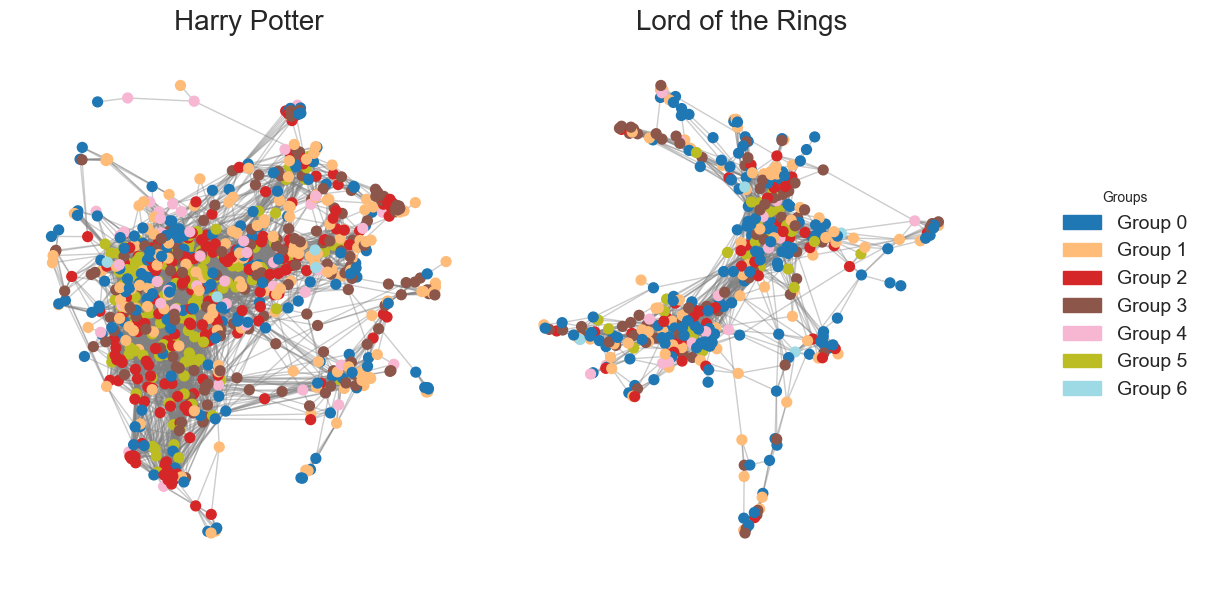

In [80]:
plot_backbones(HP.to_undirected().copy(), LOTR.to_undirected().copy(), partition, alpha_threshold=0.5, title1='Harry Potter', title2='Lord of the Rings')

### 3) Sentiment analysis

In [ ]:
# Helper functions
def plot_sentiment_distribution(sentiments, title="Sentiment Distribution"):
    values = [v for v in sentiments.values() if not np.isnan(v)]
    mean = np.mean(values)
    median = np.median(values)
    p25, p75 = np.percentile(values, [25, 75])

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=30, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='--', label=f"Mean = {mean:.2f}")
    plt.axvline(median, color='g', linestyle='--', label=f"Median = {median:.2f}")
    plt.axvline(p25, color='gray', linestyle=':', label=f"25th = {p25:.2f}")
    plt.axvline(p75, color='gray', linestyle=':', label=f"75th = {p75:.2f}")
    plt.legend()
    plt.title(title)
    plt.xlabel("Average sentiment (LabMT score)")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
def plot_single(ax, G, sentiments, title, color):
    G_nodes = G.nodes()
    sentimenst_G = [item for key, item in sentiments.items() if key in G_nodes]
    mean = np.mean(sentimenst_G)
    median = np.median(sentimenst_G)
    p25, p75 = np.percentile(sentimenst_G, [25, 75])
    ax.hist(sentimenst_G, bins=30, color=color, alpha=0.8, edgecolor="black")
    ax.axvline(mean, color='r', linestyle='--', label=f"Mean = {mean:.2f}")
    ax.axvline(median, color='g', linestyle='--', label=f"Median = {median:.2f}")
    ax.axvline(p25, color='gray', linestyle=':', label=f"25th = {p25:.2f}")
    ax.axvline(p75, color='gray', linestyle=':', label=f"75th = {p75:.2f}")
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel("Average sentiment (LabMT score)")
    ax.set_ylabel("Frequency")


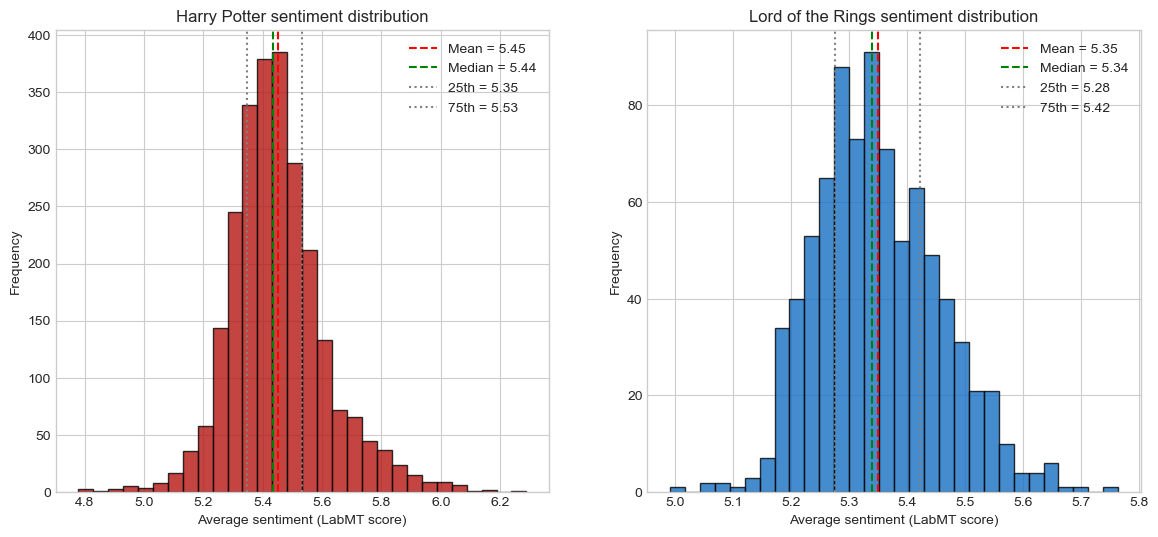

In [ ]:
node_sentiments = sentiment(G)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_single(axes[0], HP, node_sentiments, 'Harry Potter sentiment distribution', "#b51512")
plot_single(axes[1], LOTR, node_sentiments, 'Lord of the Rings sentiment distribution', "#1670c4")

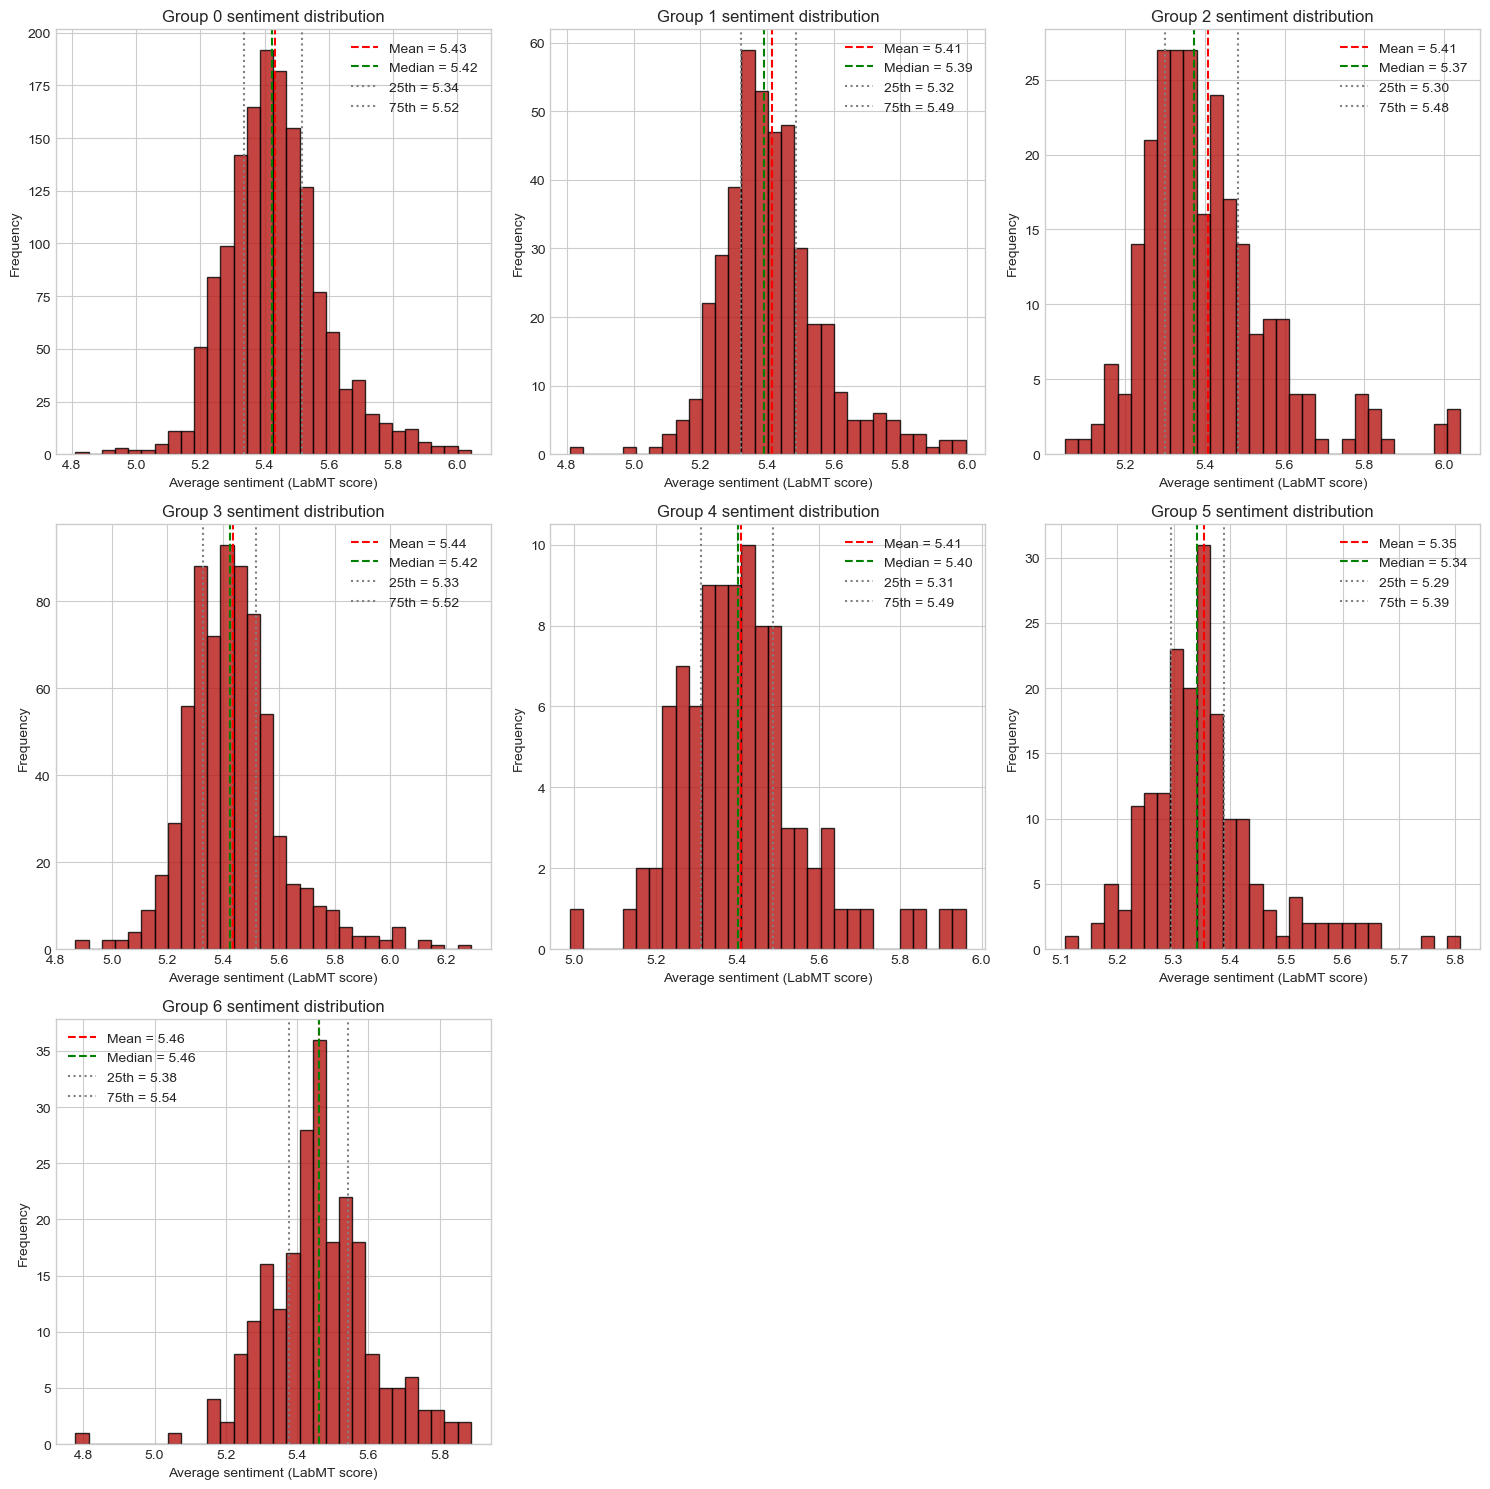

In [ ]:
# Sentiment analyse her
number_of_partitions = len(partition)
node_sentiments = sentiment(G)
cols = int(np.ceil(np.sqrt(number_of_partitions)))
rows = int(np.ceil(number_of_partitions / cols))

fig_width = cols * 5
fig_height = rows * 5
fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))

axes = np.array(axes).reshape(-1)

for i in range(number_of_partitions):
    ax = axes[i]
    subG = G.subgraph(partition[i])
    plot_single(ax, subG, node_sentiments,
                f'Group {i} sentiment distribution', "#b51512")

# Hide any unused axes
for j in range(number_of_partitions, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


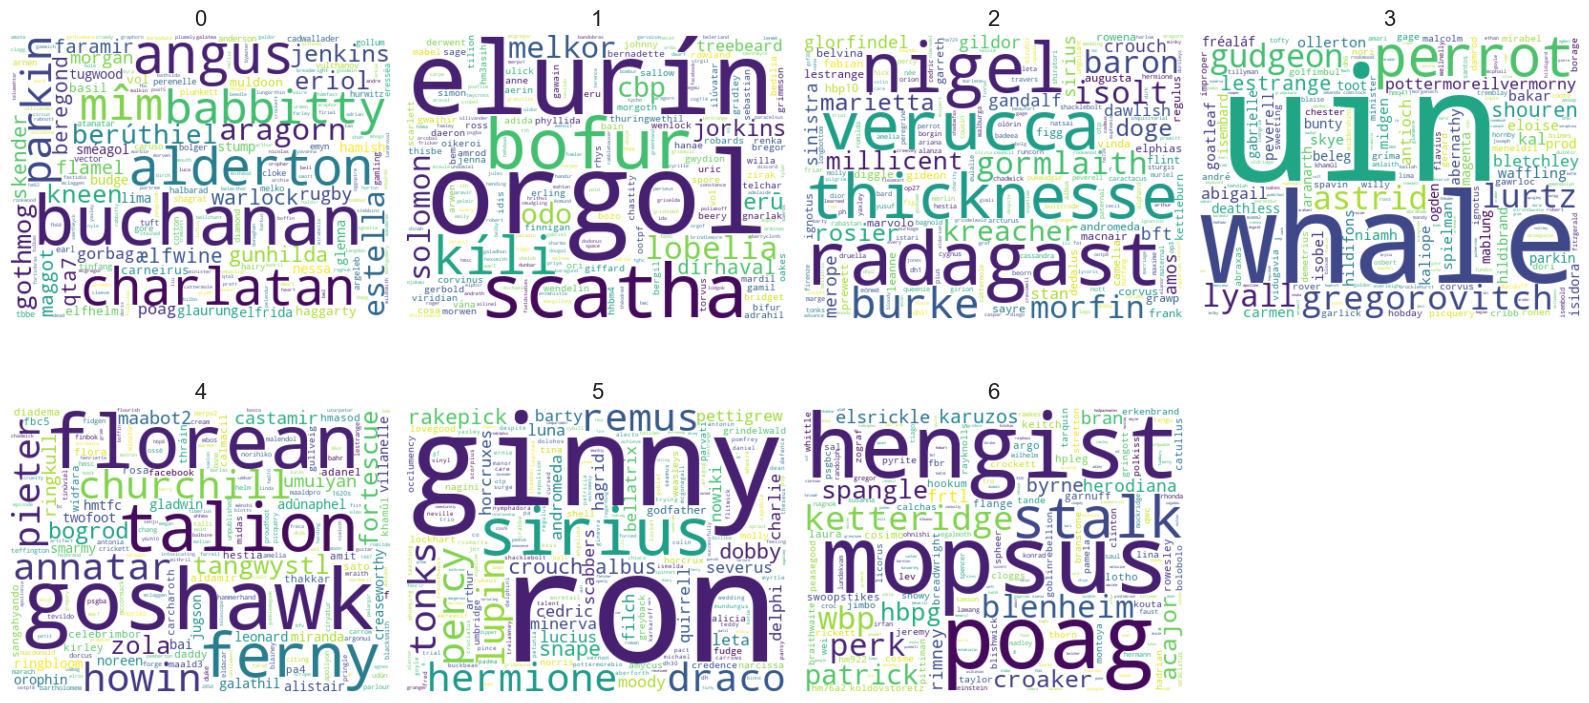

In [ ]:
corpus = create_corpus(combined_data, partition)
c2 = TF_IDF(corpus)

create_wordclouds(c2)